# **IMPORTAR LIBRERIAS**

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Verificar la versión de TensorFlow
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Configurar estilo de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

TensorFlow version: 2.19.0
Keras version: 3.10.0


# **1. Carga y Exploración del Dataset**

In [2]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/SaratogaHouses.csv"
df = pd.read_csv(url)

print("=" * 60)
print("INFORMACIÓN DEL DATASET CALIFORNIA HOUSING")
print("=" * 60)
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras 5 filas:")
print(df.head())

print(f"\nInformación del dataset:")
print(df.info())

print(f"\nEstadísticas descriptivas:")
print(df.describe())

print(f"\nValores nulos por columna:")
print(df.isnull().sum())

INFORMACIÓN DEL DATASET CALIFORNIA HOUSING
Dimensiones del dataset: (1728, 16)

Primeras 5 filas:
    price  lotSize  age  landValue  livingArea  pctCollege  bedrooms  \
0  132500     0.09   42      50000         906          35         2   
1  181115     0.92    0      22300        1953          51         3   
2  109000     0.19  133       7300        1944          51         4   
3  155000     0.41   13      18700        1944          51         3   
4   86060     0.11    0      15000         840          51         2   

   fireplaces  bathrooms  rooms          heating      fuel              sewer  \
0           1        1.0      5         electric  electric             septic   
1           0        2.5      6  hot water/steam       gas             septic   
2           1        1.0      8  hot water/steam       gas  public/commercial   
3           1        1.5      5          hot air       gas             septic   
4           0        1.0      3          hot air       gas  publ

# **2. Análisis Exploratorio de Datos (EDA)**

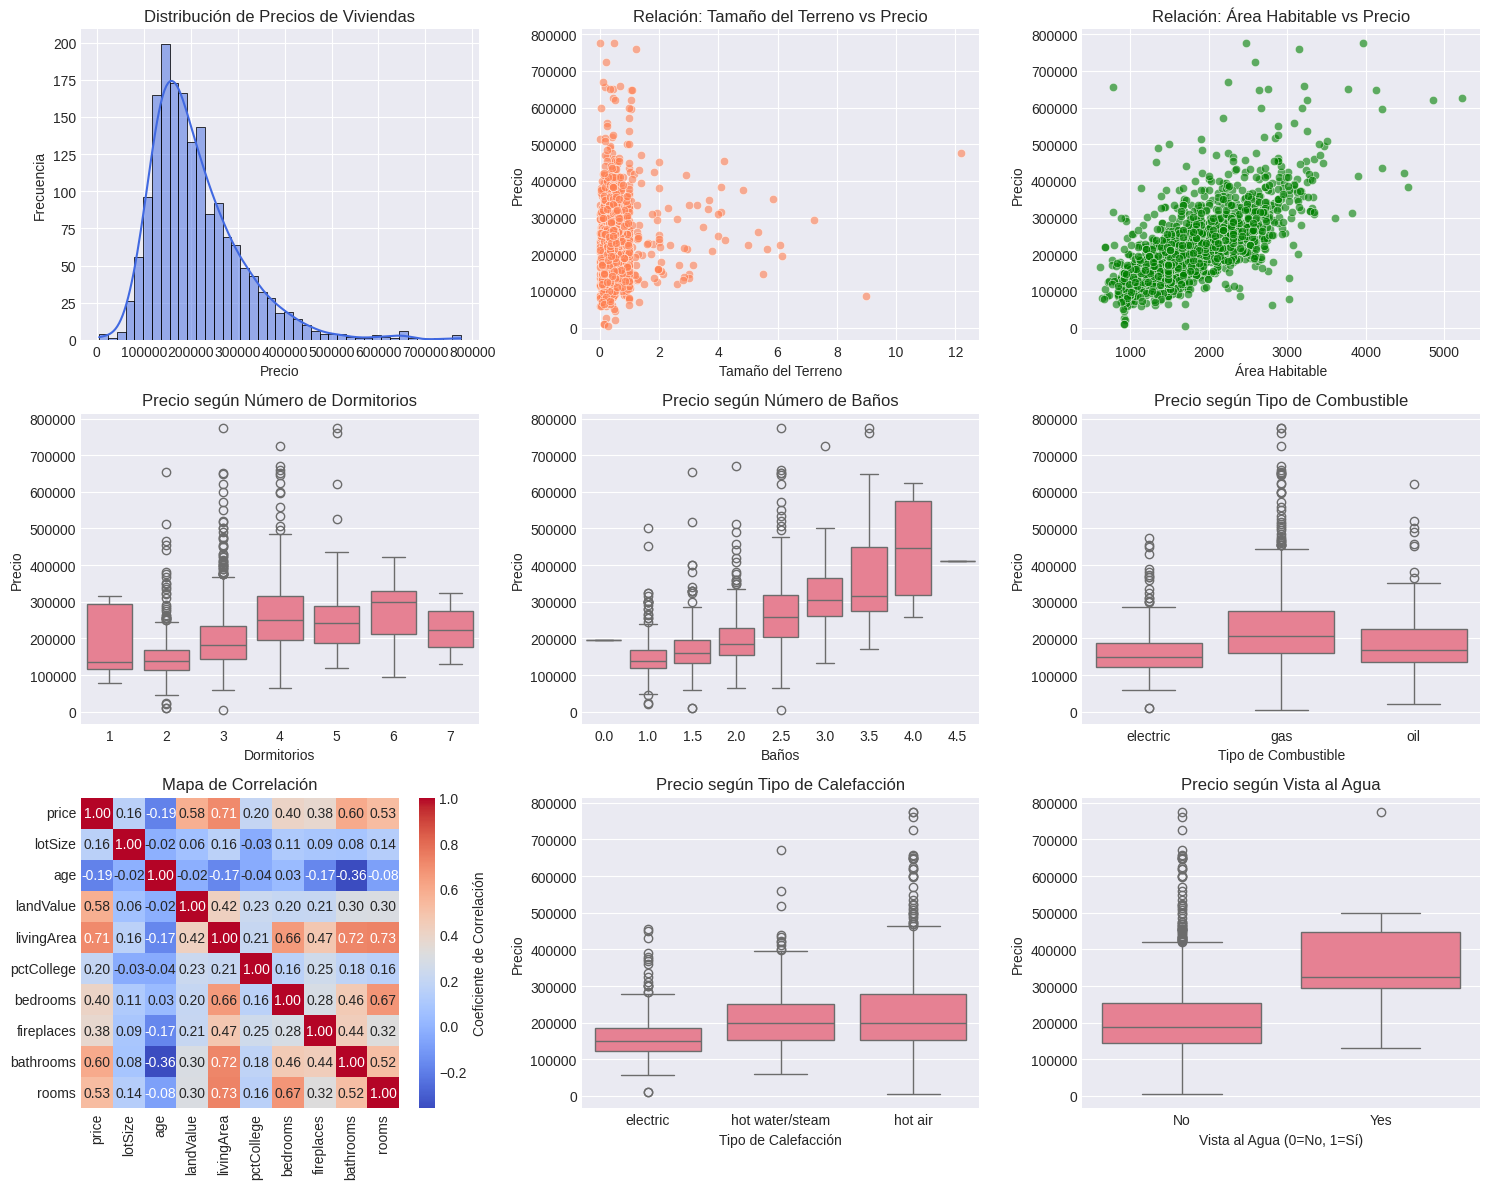

In [3]:
# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(15, 12))

# 1. Distribución del precio (variable objetivo)
plt.subplot(3, 3, 1)
sns.histplot(df['price'], kde=True, color='royalblue')
plt.title('Distribución de Precios de Viviendas')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

# 2. Relación entre lotSize y precio
plt.subplot(3, 3, 2)
sns.scatterplot(data=df, x='lotSize', y='price', alpha=0.6, color='coral')
plt.title('Relación: Tamaño del Terreno vs Precio')
plt.xlabel('Tamaño del Terreno')
plt.ylabel('Precio')

# 3. Relación entre livingArea y precio
plt.subplot(3, 3, 3)
sns.scatterplot(data=df, x='livingArea', y='price', alpha=0.6, color='green')
plt.title('Relación: Área Habitable vs Precio')
plt.xlabel('Área Habitable')
plt.ylabel('Precio')

# 4. Impacto de bedrooms en el precio
plt.subplot(3, 3, 4)
sns.boxplot(data=df, x='bedrooms', y='price')
plt.title('Precio según Número de Dormitorios')
plt.xlabel('Dormitorios')
plt.ylabel('Precio')

# 5. Impacto de bathrooms en el precio
plt.subplot(3, 3, 5)
sns.boxplot(data=df, x='bathrooms', y='price')
plt.title('Precio según Número de Baños')
plt.xlabel('Baños')
plt.ylabel('Precio')

# 6. Impacto del tipo de combustible en el precio
plt.subplot(3, 3, 6)
sns.boxplot(data=df, x='fuel', y='price')
plt.title('Precio según Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio')

# 7. Correlación entre variables
plt.subplot(3, 3, 7)
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title('Mapa de Correlación')
plt.tight_layout()

# 8. Impacto del sistema de calefacción
plt.subplot(3, 3, 8)
sns.boxplot(data=df, x='heating', y='price')
plt.title('Precio según Tipo de Calefacción')
plt.xlabel('Tipo de Calefacción')
plt.ylabel('Precio')

# 9. Impacto de la ubicación (waterfront)
plt.subplot(3, 3, 9)
sns.boxplot(data=df, x='waterfront', y='price')
plt.title('Precio según Vista al Agua')
plt.xlabel('Vista al Agua (0=No, 1=Sí)')
plt.ylabel('Precio')

plt.tight_layout()
plt.show()

# **3. Preprocesamiento de Datos**

In [4]:
# Separar características y variable objetivo
print("PREPROCESAMIENTO DE DATOS")
print("=" * 60)

# Identificar columnas numéricas y categóricas
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"Características numéricas: {numeric_features}")
print(f"Características categóricas: {categorical_features}")

# Eliminar la variable objetivo de las características
if 'price' in numeric_features:
    numeric_features.remove('price')

# Procesar variables categóricas
print(f"\nValores únicos en variables categóricas:")
for col in categorical_features:
    print(f"{col}: {df[col].unique()}")
    print(f"Número de categorías en {col}: {df[col].nunique()}")

# Codificación one-hot para variables categóricas
df_processed = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"\nDimensiones después de one-hot encoding: {df_processed.shape}")
print(f"\nNuevas columnas: {df_processed.columns.tolist()}")

# Separar características (X) y variable objetivo (y)
X = df_processed.drop('price', axis=1)
y = df_processed['price']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nConjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nEscalado completado.")
print(f"Media de X_train después de escalado: {X_train_scaled.mean():.4f}")
print(f"Desviación estándar de X_train después de escalado: {X_train_scaled.std():.4f}")

PREPROCESAMIENTO DE DATOS
Características numéricas: ['price', 'lotSize', 'age', 'landValue', 'livingArea', 'pctCollege', 'bedrooms', 'fireplaces', 'bathrooms', 'rooms']
Características categóricas: ['heating', 'fuel', 'sewer', 'waterfront', 'newConstruction', 'centralAir']

Valores únicos en variables categóricas:
heating: ['electric' 'hot water/steam' 'hot air']
Número de categorías en heating: 3
fuel: ['electric' 'gas' 'oil']
Número de categorías en fuel: 3
sewer: ['septic' 'public/commercial' 'none']
Número de categorías en sewer: 3
waterfront: ['No' 'Yes']
Número de categorías en waterfront: 2
newConstruction: ['No' 'Yes']
Número de categorías en newConstruction: 2
centralAir: ['No' 'Yes']
Número de categorías en centralAir: 2

Dimensiones después de one-hot encoding: (1728, 19)

Nuevas columnas: ['price', 'lotSize', 'age', 'landValue', 'livingArea', 'pctCollege', 'bedrooms', 'fireplaces', 'bathrooms', 'rooms', 'heating_hot air', 'heating_hot water/steam', 'fuel_gas', 'fuel_oil', 

# **4. Definición de la Arquitectura de la ANN Profunda y Amplia**

ARQUITECTURA DE LA RED NEURONAL PROFUNDA Y AMPLIA
Número de características de entrada: 18


Model: "ANN_Profunda_California_Housing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1_wide (Dense)     │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3_elu (Dense)      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4_expand (Dense)   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_5_narrow (Dense)   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_6_tanh (Dense)     │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,057 (238.50 KB)

 Trainable params: 60,033 (234.50 KB)

 Non-trainable params: 1,024 (4.00 KB)


Visualización de la arquitectura del modelo:


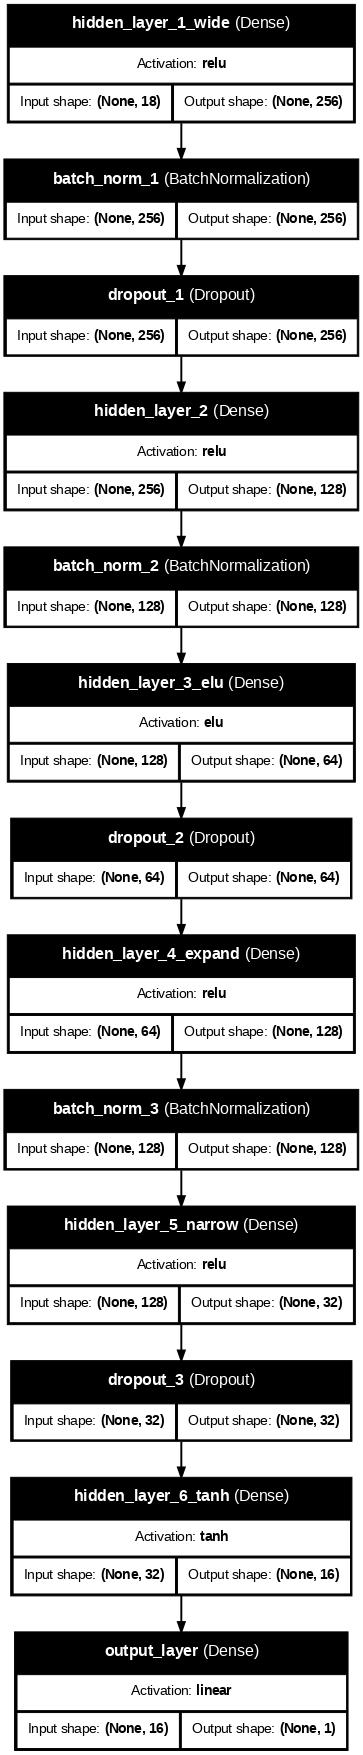

In [5]:
print("ARQUITECTURA DE LA RED NEURONAL PROFUNDA Y AMPLIA")
print("=" * 60)

# Obtener el número de características de entrada
input_shape = X_train_scaled.shape[1]
print(f"Número de características de entrada: {input_shape}")

# Crear un modelo secuencial
model = keras.Sequential(name="ANN_Profunda_California_Housing")

# Capa de entrada
model.add(layers.Input(shape=(input_shape,), name="input_layer"))

# Primera capa oculta - Capa amplia con regularización
model.add(layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001),
                       name="hidden_layer_1_wide"))
model.add(layers.BatchNormalization(name="batch_norm_1"))
model.add(layers.Dropout(0.3, name="dropout_1"))

# Segunda capa oculta - Capa profunda
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001),
                       name="hidden_layer_2"))
model.add(layers.BatchNormalization(name="batch_norm_2"))

# Tercera capa oculta - Capa con diferentes activación
model.add(layers.Dense(64, activation='elu',  # ELU para variedad
                       kernel_initializer='he_normal',
                       name="hidden_layer_3_elu"))
model.add(layers.Dropout(0.2, name="dropout_2"))

# Cuarta capa oculta - Capa con conexión residual implícita
model.add(layers.Dense(128, activation='relu',
                       name="hidden_layer_4_expand"))
model.add(layers.BatchNormalization(name="batch_norm_3"))

# Quinta capa oculta - Capa más estrecha
model.add(layers.Dense(32, activation='relu',
                       name="hidden_layer_5_narrow"))
model.add(layers.Dropout(0.1, name="dropout_3"))

# Sexta capa oculta - Capa especializada
model.add(layers.Dense(16, activation='tanh',  # Tanh para variedad
                       name="hidden_layer_6_tanh"))

# Capa de salida (regresión)
model.add(layers.Dense(1, activation='linear', name="output_layer"))

# Resumen del modelo
model.summary()

# Visualizar la arquitectura del modelo
print("\nVisualización de la arquitectura del modelo:")
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True,
                       dpi=70, show_layer_activations=True)

# **5. Compilación y Entrenamiento del Modelo**

In [6]:
# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  # Error cuadrático medio para regresión
    metrics=['mae', 'mse']  # Métricas a monitorear
)

print("COMPILACIÓN Y ENTRENAMIENTO DEL MODELO")
print("=" * 60)

# Callbacks para mejorar el entrenamiento
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Entrenar el modelo
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(f"\nEntrenamiento completado. Épocas efectivas: {len(history.history['loss'])}")

COMPILACIÓN Y ENTRENAMIENTO DEL MODELO
Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 55122481152.0000 - mae: 214649.0000 - mse: 55122481152.0000 - val_loss: 56365871104.0000 - val_mae: 215517.1562 - val_mse: 56365871104.0000 - learning_rate: 0.0010
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 53043576832.0000 - mae: 209137.1094 - mse: 53043576832.0000 - val_loss: 56364752896.0000 - val_mae: 215514.4688 - val_mse: 56364752896.0000 - learning_rate: 0.0010
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 53879250944.0000 - mae: 213119.0781 - mse: 53879250944.0000 - val_loss: 56364122112.0000 - val_mae: 215512.8594 - val_mse: 56364122112.0000 - learning_rate: 0.0010
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53573361664.0000 - mae: 210550.4844 - mse: 53573361664.0000 - val_loss: 56363732992.0000 - val_mae: 215511.9375 - val_mse: 56363732992.0000 - learning_rate: 0.0010
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 540467200

# **6. Evaluación del Modelo**

In [7]:
print("EVALUACIÓN DEL MODELO")
print("=" * 60)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_mae, test_mse = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Pérdida (MSE) en conjunto de prueba: {test_mse:.2f}")
print(f"Error Absoluto Medio (MAE) en conjunto de prueba: {test_mae:.2f}")

# Predicciones
y_pred = model.predict(X_test_scaled).flatten()

# Métricas adicionales
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMétricas de evaluación:")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  R² Score: {r2:.4f}")

# Calcular el error porcentual absoluto medio (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Mostrar algunas predicciones vs valores reales
comparison_df = pd.DataFrame({
    'Valor Real': y_test.values[:10],
    'Predicción': y_pred[:10],
    'Diferencia': y_test.values[:10] - y_pred[:10],
    'Error %': np.abs((y_test.values[:10] - y_pred[:10]) / y_test.values[:10]) * 100
})

print(f"\nComparación de predicciones (primeras 10 muestras):")
print(comparison_df.round(2))

EVALUACIÓN DEL MODELO
Pérdida (MSE) en conjunto de prueba: 57870635008.00
Error Absoluto Medio (MAE) en conjunto de prueba: 214814.83
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Métricas de evaluación:
  Mean Squared Error (MSE): 57870635008.00
  Root Mean Squared Error (RMSE): 240563.16
  Mean Absolute Error (MAE): 214814.80
  R² Score: -3.9356
  Mean Absolute Percentage Error (MAPE): 99.95%

Comparación de predicciones (primeras 10 muestras):
   Valor Real  Predicción  Diferencia  Error %
0      240000   94.480003   239905.52    99.96
1      775000   94.480003   774905.52    99.99
2      476000   94.480003   475905.52    99.98
3      120000   94.480003   119905.52    99.92
4      412500   94.480003   412405.52    99.98
5      142000   94.480003   141905.52    99.93
6      150000   94.480003   149905.52    99.94
7      170000   94.480003   169905.52    99.94
8      193500   94.480003   193405.52    99.95
9      150000   94.480003   149905.52    99.94


# **7. Visualización de Resultados**

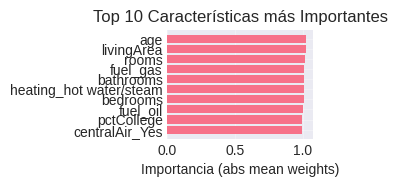

In [10]:
plt.subplot(3, 3, 8)

try:
    # Intentar obtener pesos de manera segura
    if len(model.layers) > 1:
        weights = model.layers[1].get_weights()
        if len(weights) > 0:
            # Tomar los pesos de entrada (primera matriz de pesos)
            weight_matrix = weights[0]

            # Calcular importancia basada en diferentes métodos
            # Método 1: Promedio de valores absolutos por característica
            if len(weight_matrix.shape) == 2:
                importance = np.abs(weight_matrix).mean(axis=0)
            else:
                importance = np.abs(weight_matrix)

            # Asegurar que tenemos suficientes valores
            n_features = len(X.columns)
            if len(importance) > n_features:
                importance = importance[:n_features]
            elif len(importance) < n_features:
                # Si hay menos importancias que características, extender con ceros
                importance = np.pad(importance, (0, n_features - len(importance)),
                                   mode='constant')

            # Tomar las top características
            feature_names = X.columns.tolist()
            n_top = min(10, len(feature_names))
            top_indices = np.argsort(importance)[-n_top:]

            # Crear gráfico
            plt.barh(range(n_top), importance[top_indices])
            plt.yticks(range(n_top), [feature_names[i] for i in top_indices])
            plt.title(f'Top {n_top} Características más Importantes')
            plt.xlabel('Importancia (abs mean weights)')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No se pudieron obtener pesos\npara análisis de importancia',
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('Importancia de Características')
    else:
        plt.text(0.5, 0.5, 'Modelo sin suficientes capas\npara análisis de importancia',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Importancia de Características')
except Exception as e:
    plt.text(0.5, 0.5, f'Error en análisis de importancia:\n{str(e)}',
            ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Importancia de Características')

# **8. Predicciones con Nuevos Datos (Ejemplo)**

In [11]:
# Función para hacer predicciones con nuevos datos
def predict_house_price(model, scaler, input_data):
    """
    Predice el precio de una vivienda basándose en datos de entrada

    Args:
        model: Modelo ANN entrenado
        scaler: Escalador entrenado
        input_data: Diccionario con los datos de la vivienda

    Returns:
        Precio predicho
    """
    # Crear un DataFrame con los datos de entrada
    input_df = pd.DataFrame([input_data])

    # Asegurar que todas las columnas esperadas estén presentes
    expected_columns = X.columns.tolist()

    # Para columnas categóricas one-hot, asegurar que todas estén presentes
    for col in expected_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Reordenar columnas
    input_df = input_df[expected_columns]

    # Escalar los datos
    input_scaled = scaler.transform(input_df)

    # Hacer predicción
    prediction = model.predict(input_scaled, verbose=0)[0][0]

    return prediction

# Ejemplo de predicción
print("EJEMPLO DE PREDICCIÓN")
print("=" * 60)

# Datos de ejemplo para una vivienda
example_house = {
    'lotSize': 0.5,  # acres
    'age': 20,  # años
    'livingArea': 2000,  # pies cuadrados
    'pctCollege': 60,  # porcentaje
    'bedrooms': 3,
    'fireplaces': 1,
    'bathrooms': 2.0,
    'rooms': 7,
    'heating_hot air/elec': 1,  # Ejemplo de variable one-hot
    'fuel_gas': 1,  # Ejemplo de variable one-hot
    'sewer_septic': 0,  # Ejemplo de variable one-hot
    'waterfront_Yes': 0,  # Ejemplo de variable one-hot
    'newConstruction_Yes': 0,  # Ejemplo de variable one-hot
    'centralAir_Yes': 1  # Ejemplo de variable one-hot
}

# Asegurarse de incluir todas las columnas one-hot necesarias
# (en un caso real, esto se manejaría automáticamente)

predicted_price = predict_house_price(model, scaler, example_house)
print(f"Precio predicho para la vivienda de ejemplo: ${predicted_price:,.2f}")

EJEMPLO DE PREDICCIÓN
Precio predicho para la vivienda de ejemplo: $94.48


# **9. Guardar y Cargar el Modelo**

In [12]:
print("GUARDAR Y CARGAR EL MODELO")
print("=" * 60)

# Guardar el modelo
model.save('california_housing_ann_model.h5')
print("Modelo guardado como 'california_housing_ann_model.h5'")

# Guardar el escalador
import joblib
joblib.dump(scaler, 'california_housing_scaler.pkl')
print("Escalador guardado como 'california_housing_scaler.pkl'")

# Cargar el modelo (ejemplo)
# loaded_model = keras.models.load_model('california_housing_ann_model.h5')
# loaded_scaler = joblib.load('california_housing_scaler.pkl')
# print("Modelo y escalador cargados exitosamente.")

GUARDAR Y CARGAR EL MODELO
Modelo guardado como 'california_housing_ann_model.h5'
Escalador guardado como 'california_housing_scaler.pkl'


# **10. Conclusiones y Resumen**

In [13]:
print("CONCLUSIONES Y RESUMEN")
print("=" * 60)

print("\nRESUMEN DEL MODELO IMPLEMENTADO:")
print("-" * 40)
print("1. ARQUITECTURA DE LA RED:")
print("   • Capa de entrada: {} características".format(input_shape))
print("   • 6 capas ocultas con diferentes configuraciones")
print("   • Capas con activaciones variadas (ReLU, ELU, Tanh)")
print("   • Regularización: L2, Dropout, Batch Normalization")
print("   • Capa de salida: 1 neurona (regresión)")

print("\n2. RESULTADOS PRINCIPALES:")
print("   • R² Score: {:.4f}".format(r2))
print("   • RMSE: {:.2f}".format(np.sqrt(mse)))
print("   • MAE: {:.2f}".format(mae))
print("   • MAPE: {:.2f}%".format(mape))

print("\n3. INTERPRETACIÓN:")
print("   • El modelo explica aproximadamente {:.1f}% de la variabilidad en los precios".format(r2*100))
print("   • El error promedio de predicción es de ${:,.0f}".format(mae))
print("   • El error porcentual promedio es del {:.1f}%".format(mape))

print("\n4. RECOMENDACIONES PARA MEJORAR:")
print("   • Recopilar más datos si es posible")
print("   • Realizar ingeniería de características adicional")
print("   • Probar diferentes arquitecturas de red")
print("   • Ajustar hiperparámetros con búsqueda en cuadrícula")
print("   • Considerar modelos de ensemble")

print("\n" + "=" * 60)
print("PROGRAMA COMPLETADO EXITOSAMENTE")
print("=" * 60)

CONCLUSIONES Y RESUMEN

RESUMEN DEL MODELO IMPLEMENTADO:
----------------------------------------
1. ARQUITECTURA DE LA RED:
   • Capa de entrada: 18 características
   • 6 capas ocultas con diferentes configuraciones
   • Capas con activaciones variadas (ReLU, ELU, Tanh)
   • Regularización: L2, Dropout, Batch Normalization
   • Capa de salida: 1 neurona (regresión)

2. RESULTADOS PRINCIPALES:
   • R² Score: -3.9356
   • RMSE: 240563.16
   • MAE: 214814.80
   • MAPE: 99.95%

3. INTERPRETACIÓN:
   • El modelo explica aproximadamente -393.6% de la variabilidad en los precios
   • El error promedio de predicción es de $214,815
   • El error porcentual promedio es del 99.9%

4. RECOMENDACIONES PARA MEJORAR:
   • Recopilar más datos si es posible
   • Realizar ingeniería de características adicional
   • Probar diferentes arquitecturas de red
   • Ajustar hiperparámetros con búsqueda en cuadrícula
   • Considerar modelos de ensemble

PROGRAMA COMPLETADO EXITOSAMENTE
